## EXAMPLE 1

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.9 MB/s eta 0:00:00


In [3]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# For hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Bayesian Optimization
import optuna

# For a simple Deep Learning model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [4]:
# ============================================
# 2. GENERATE FAKE DATA
# ============================================

np.random.seed(42)
rows = 1500   # more than 1000 rows

data = pd.DataFrame({
    "age": np.random.randint(18, 65, rows),
    "monthly_spend": np.random.uniform(100, 5000, rows),
    "years_with_company": np.random.randint(0, 10, rows),
    "num_complaints": np.random.randint(0, 5, rows),
    "is_active_member": np.random.randint(0, 2, rows),
})

# Label generation logic: higher complaints, lower spend, low engagement → higher churn
data["churn"] = (
    (data["num_complaints"] > 2).astype(int)
    | (data["is_active_member"] == 0)
    | (data["monthly_spend"] < 500)
)

data["churn"] = data["churn"].astype(int)

data.head()


,age,monthly_spend,years_with_company,num_complaints,is_active_member,churn
0,56,4039.487199,8,3,1,1
1,46,2738.167303,0,0,1,0
2,32,3342.110358,3,0,1,0
3,60,3715.493258,2,1,1,0
4,25,2648.823738,1,2,0,1


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 1500 non-null   int64  
 1   monthly_spend       1500 non-null   float64
 2   years_with_company  1500 non-null   int64  
 3   num_complaints      1500 non-null   int64  
 4   is_active_member    1500 non-null   int64  
 5   churn               1500 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 70.4 KB
None

Missing Values:
age                   0
monthly_spend         0
years_with_company    0
num_complaints        0
is_active_member      0
churn                 0
dtype: int64

Summary Stats:
               age  monthly_spend  years_with_company  num_complaints  \
count  1500.000000    1500.000000         1500.000000     1500.000000   
mean     41.285333    2530.288977            4.521333        2.000000   
std      13.480495    1421

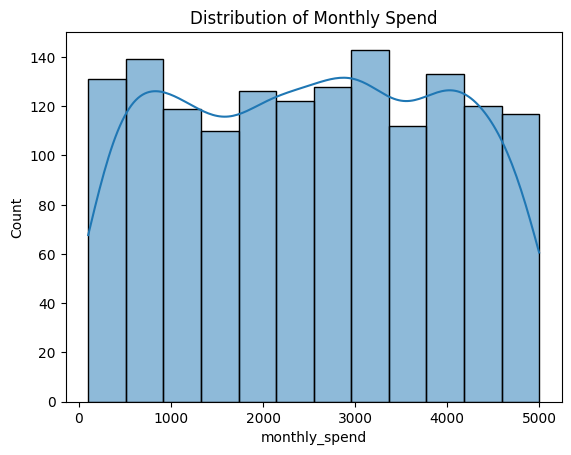

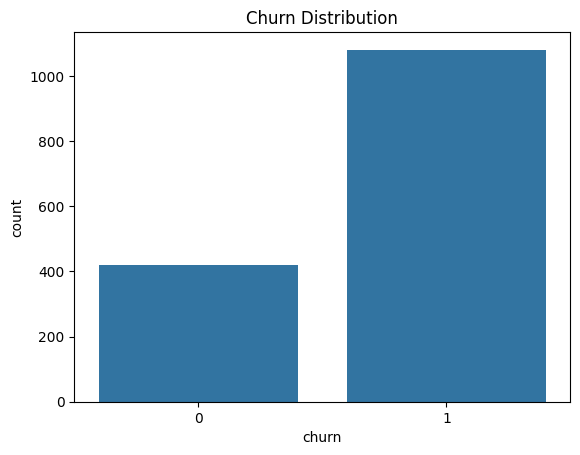

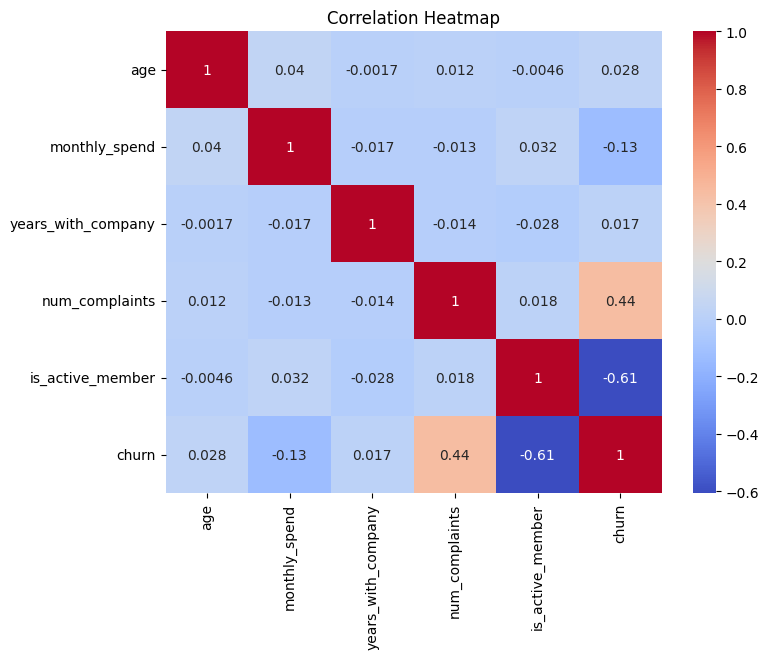

In [5]:
# ============================================
# 3. BASIC EDA
# ============================================

print("Data Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nSummary Stats:")
print(data.describe())

# Plot distributions
sns.histplot(data["monthly_spend"], kde=True)
plt.title("Distribution of Monthly Spend")
plt.show()

sns.countplot(x="churn", data=data)
plt.title("Churn Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [6]:
# ============================================
# 4. SPLIT & SCALE
# ============================================
X = data.drop("churn", axis=1)
y = data["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
# ============================================
# 5. BASELINE MODEL
# ============================================
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Baseline Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       103
           1       0.95      0.99      0.97       197

    accuracy                           0.96       300
   macro avg       0.97      0.95      0.95       300
weighted avg       0.96      0.96      0.96       300



In [8]:
# ============================================
# 6. GRID SEARCH
# ============================================
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}

grid = GridSearchCV(LogisticRegression(max_iter=500), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Params (Grid Search):", grid.best_params_)

grid_preds = grid.predict(X_test_scaled)
print("Grid Search Accuracy:", accuracy_score(y_test, grid_preds))


Best Params (Grid Search): {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Grid Search Accuracy: 0.96


In [9]:
# ============================================
# 7. RANDOM SEARCH
# ============================================
param_dist = {
    "C": np.logspace(-3, 3, 100),
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=500),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print("Best Params (Random Search):", random_search.best_params_)

random_preds = random_search.predict(X_test_scaled)
print("Random Search Accuracy:", accuracy_score(y_test, random_preds))


Best Params (Random Search): {'solver': 'lbfgs', 'penalty': 'l2', 'C': np.float64(107.22672220103232)}
Random Search Accuracy: 0.96


In [10]:
# ============================================
# 8. BAYESIAN OPTIMIZATION (OPTUNA)
# ============================================

def objective(trial):
    C = trial.suggest_loguniform("C", 1e-4, 10)

    model = LogisticRegression(
        C=C,
        solver="lbfgs",
        max_iter=500
    )

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return accuracy_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best Params (Bayesian Optimization):", study.best_params)
print("Best Score:", study.best_value)


[I 2025-11-19 05:57:23,269] A new study created in memory with name: no-name-19598577-c96b-43fb-97dc-05f234b0c1d9
/tmp/ipython-input-279264513.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform("C", 1e-4, 10)
[I 2025-11-19 05:57:23,280] Trial 0 finished with value: 0.8666666666666667 and parameters: {'C': 0.00896765342437605}. Best is trial 0 with value: 0.8666666666666667.
/tmp/ipython-input-279264513.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform("C", 1e-4, 10)
[I 2025-11-19 05:57:23,289] Trial 1 finished with value: 0.9566666666666667 and parameters: {'C': 0.16084322443745774}. Best is trial 1 with value

Best Params (Bayesian Optimization): {'C': 0.9158485243381691}
Best Score: 0.96


In [11]:
# ============================================
# 9. SIMPLE DEEP LEARNING MODEL (Keras)
# ============================================

model_dl = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dl.compile(optimizer=Adam(0.001), loss="binary_crossentropy", metrics=["accuracy"])

history = model_dl.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

dl_acc = model_dl.evaluate(X_test_scaled, y_test, verbose=0)[1]
print("Deep Learning Model Accuracy:", dl_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5993 - loss: 0.6845 - val_accuracy: 0.7375 - val_loss: 0.6327
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7570 - loss: 0.6169 - val_accuracy: 0.8375 - val_loss: 0.5657
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8195 - loss: 0.5474 - val_accuracy: 0.8375 - val_loss: 0.4951
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8499 - loss: 0.4807 - val_accuracy: 0.8708 - val_loss: 0.4252
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9105 - loss: 0.3872 - val_accuracy: 0.8958 - val_loss: 0.3565
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9184 - loss: 0.3233 - val_accuracy: 0.9292 - val_loss: 0.2919
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9366 - loss: 0.2700 - val_accuracy: 0.9458 - val_loss: 0.2391
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9571 - loss: 0.2006 - val_accuracy: 0.9542 - va

## EXAMPLE 2

In [12]:
# ============================================
# 1. IMPORTS
# ============================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

import optuna


In [13]:
# ============================================
# 2. GENERATE FAKE DATA
# ============================================
np.random.seed(42)
rows = 1500

data = pd.DataFrame({
    "age": np.random.randint(18, 65, rows),
    "monthly_spend": np.random.uniform(100, 5000, rows),
    "years_with_company": np.random.randint(0, 10, rows),
    "num_complaints": np.random.randint(0, 5, rows),
    "is_active_member": np.random.randint(0, 2, rows),
})

# Churn logic
data["churn"] = (
    (data["num_complaints"] > 2).astype(int)
    | (data["is_active_member"] == 0)
    | (data["monthly_spend"] < 500)
).astype(int)

data.head()


,age,monthly_spend,years_with_company,num_complaints,is_active_member,churn
0,56,4039.487199,8,3,1,1
1,46,2738.167303,0,0,1,0
2,32,3342.110358,3,0,1,0
3,60,3715.493258,2,1,1,0
4,25,2648.823738,1,2,0,1



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 1500 non-null   int64  
 1   monthly_spend       1500 non-null   float64
 2   years_with_company  1500 non-null   int64  
 3   num_complaints      1500 non-null   int64  
 4   is_active_member    1500 non-null   int64  
 5   churn               1500 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 70.4 KB
None

Summary Stats:
               age  monthly_spend  years_with_company  num_complaints  \
count  1500.000000    1500.000000         1500.000000     1500.000000   
mean     41.285333    2530.288977            4.521333        2.000000   
std      13.480495    1421.053108            2.883589        1.415628   
min      18.000000     100.923158            0.000000        0.000000   
25%      29.000000    1261.138154            2.000000

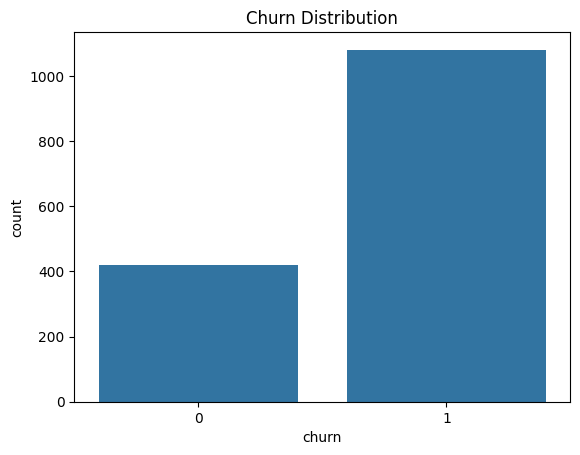

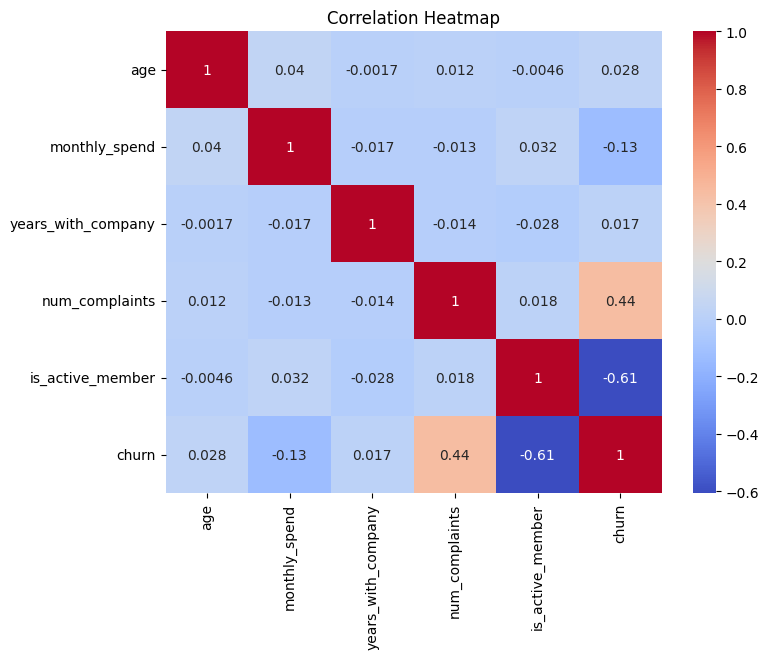

In [14]:
# ============================================
# 3. BASIC EDA
# ============================================

print("\nData Info:")
print(data.info())

print("\nSummary Stats:")
print(data.describe())

sns.countplot(x=data["churn"])
plt.title("Churn Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [15]:
# ============================================
# 4. SPLIT & SCALE
# ============================================
X = data.drop("churn", axis=1)
y = data["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [16]:
# ============================================
# 5. BUILD DL MODEL FUNCTION
# ============================================
def build_model(lr=0.001, hidden_units=16):
    model = Sequential([
        Dense(hidden_units, activation="relu", input_shape=(X_train.shape[1],)),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [17]:
# ============================================
# 6. BASELINE DL MODEL
# ============================================
baseline_model = build_model()
history = baseline_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

baseline_acc = baseline_model.evaluate(X_test, y_test, verbose=0)[1]
print("Baseline DL Model Accuracy:", baseline_acc)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2287 - loss: 0.8579 - val_accuracy: 0.4125 - val_loss: 0.7320
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4601 - loss: 0.7022 - val_accuracy: 0.6708 - val_loss: 0.6345
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7089 - loss: 0.6198 - val_accuracy: 0.7458 - val_loss: 0.5722
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7557 - loss: 0.5513 - val_accuracy: 0.7458 - val_loss: 0.5193
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7306 - loss: 0.5196 - val_accuracy: 0.7458 - val_loss: 0.4728
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7311 - loss: 0.4564 - val_accuracy: 0.7583 - val_loss: 0.4275
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7673 - loss: 0.4132 - val_accuracy: 0.8083 - val_loss: 0.3854
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8244 - loss: 0.3699 - val_accuracy: 0.8792 - val_loss: 0.3

In [18]:
# ============================================
# 7. GRID SEARCH FOR DL
# ============================================
lr_values = [0.1, 0.01, 0.001]
hidden_units_values = [8, 16, 32]

best_acc = 0
best_params = {}

for lr in lr_values:
    for hu in hidden_units_values:
        print(f"\n🔍 Training with LR={lr}, Hidden Units={hu}")

        model = build_model(lr=lr, hidden_units=hu)
        model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

        acc = model.evaluate(X_test, y_test, verbose=0)[1]

        if acc > best_acc:
            best_acc = acc
            best_params = {"lr": lr, "hidden_units": hu}

print("\nBest Grid Search Accuracy:", best_acc)
print("Best Params:", best_params)



🔍 Training with LR=0.1, Hidden Units=8

🔍 Training with LR=0.1, Hidden Units=16

🔍 Training with LR=0.1, Hidden Units=32

🔍 Training with LR=0.01, Hidden Units=8

🔍 Training with LR=0.01, Hidden Units=16

🔍 Training with LR=0.01, Hidden Units=32

🔍 Training with LR=0.001, Hidden Units=8

🔍 Training with LR=0.001, Hidden Units=16

🔍 Training with LR=0.001, Hidden Units=32

Best Grid Search Accuracy: 1.0
Best Params: {'lr': 0.01, 'hidden_units': 32}


In [19]:
# ============================================
# 8. RANDOM SEARCH FOR DL
# ============================================
import random

search_space = 10  # random trials
best_acc_rs = 0
best_params_rs = {}

for _ in range(search_space):
    lr = 10 ** np.random.uniform(-4, -1)        # random LR in log scale
    hu = random.choice([8, 16, 32, 64])         # random units

    print(f"\n🎲 Trying LR={lr:.5f}, HiddenUnits={hu}")

    model = build_model(lr=lr, hidden_units=hu)
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    acc = model.evaluate(X_test, y_test, verbose=0)[1]

    if acc > best_acc_rs:
        best_acc_rs = acc
        best_params_rs = {"lr": lr, "hidden_units": hu}

print("\nBest Random Search Accuracy:", best_acc_rs)
print("Best Params:", best_params_rs)



🎲 Trying LR=0.00102, HiddenUnits=32

🎲 Trying LR=0.00529, HiddenUnits=16

🎲 Trying LR=0.00350, HiddenUnits=64

🎲 Trying LR=0.00347, HiddenUnits=8

🎲 Trying LR=0.00021, HiddenUnits=32

🎲 Trying LR=0.00186, HiddenUnits=32

🎲 Trying LR=0.00228, HiddenUnits=8

🎲 Trying LR=0.01588, HiddenUnits=8

🎲 Trying LR=0.03312, HiddenUnits=32

🎲 Trying LR=0.00431, HiddenUnits=64

Best Random Search Accuracy: 1.0
Best Params: {'lr': 0.0035022948441748194, 'hidden_units': 64}


In [20]:
# ============================================
# 9. BAYESIAN OPTIMIZATION WITH OPTUNA
# ============================================

def objective(trial):
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
    hu = trial.suggest_int("hidden_units", 8, 64)

    model = build_model(lr=lr, hidden_units=hu)

    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    preds = model.predict(X_test)
    preds = (preds > 0.5).astype(int)

    return accuracy_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("\nBest Bayesian Optimization Accuracy:", study.best_value)
print("Best Params:", study.best_params)


[I 2025-11-19 06:00:01,060] A new study created in memory with name: no-name-2f122c73-bbfc-4c3e-98da-381709eabe5b
/tmp/ipython-input-987844233.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


[I 2025-11-19 06:00:04,484] Trial 0 finished with value: 0.9966666666666667 and parameters: {'lr': 0.004493096598843572, 'hidden_units': 46}. Best is trial 0 with value: 0.9966666666666667.
/tmp/ipython-input-987844233.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


[I 2025-11-19 06:00:06,889] Trial 1 finished with value: 0.9933333333333333 and parameters: {'lr': 0.02836979678342588, 'hidden_units': 21}. Best is trial 0 with value: 0.9966666666666667.
/tmp/ipython-input-987844233.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


[I 2025-11-19 06:00:52,508] Trial 18 finished with value: 0.9833333333333333 and parameters: {'lr': 0.0012004009628792138, 'hidden_units': 41}. Best is trial 7 with value: 1.0.
/tmp/ipython-input-987844233.py:6: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


[I 2025-11-19 06:00:54,853] Trial 19 finished with value: 0.83 and parameters: {'lr': 0.00010109273840088765, 'hidden_units': 52}. Best is trial 7 with value: 1.0.



Best Bayesian Optimization Accuracy: 1.0
Best Params: {'lr': 0.002858640299776523, 'hidden_units': 45}
